(244, 7)
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_742/2469471215.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


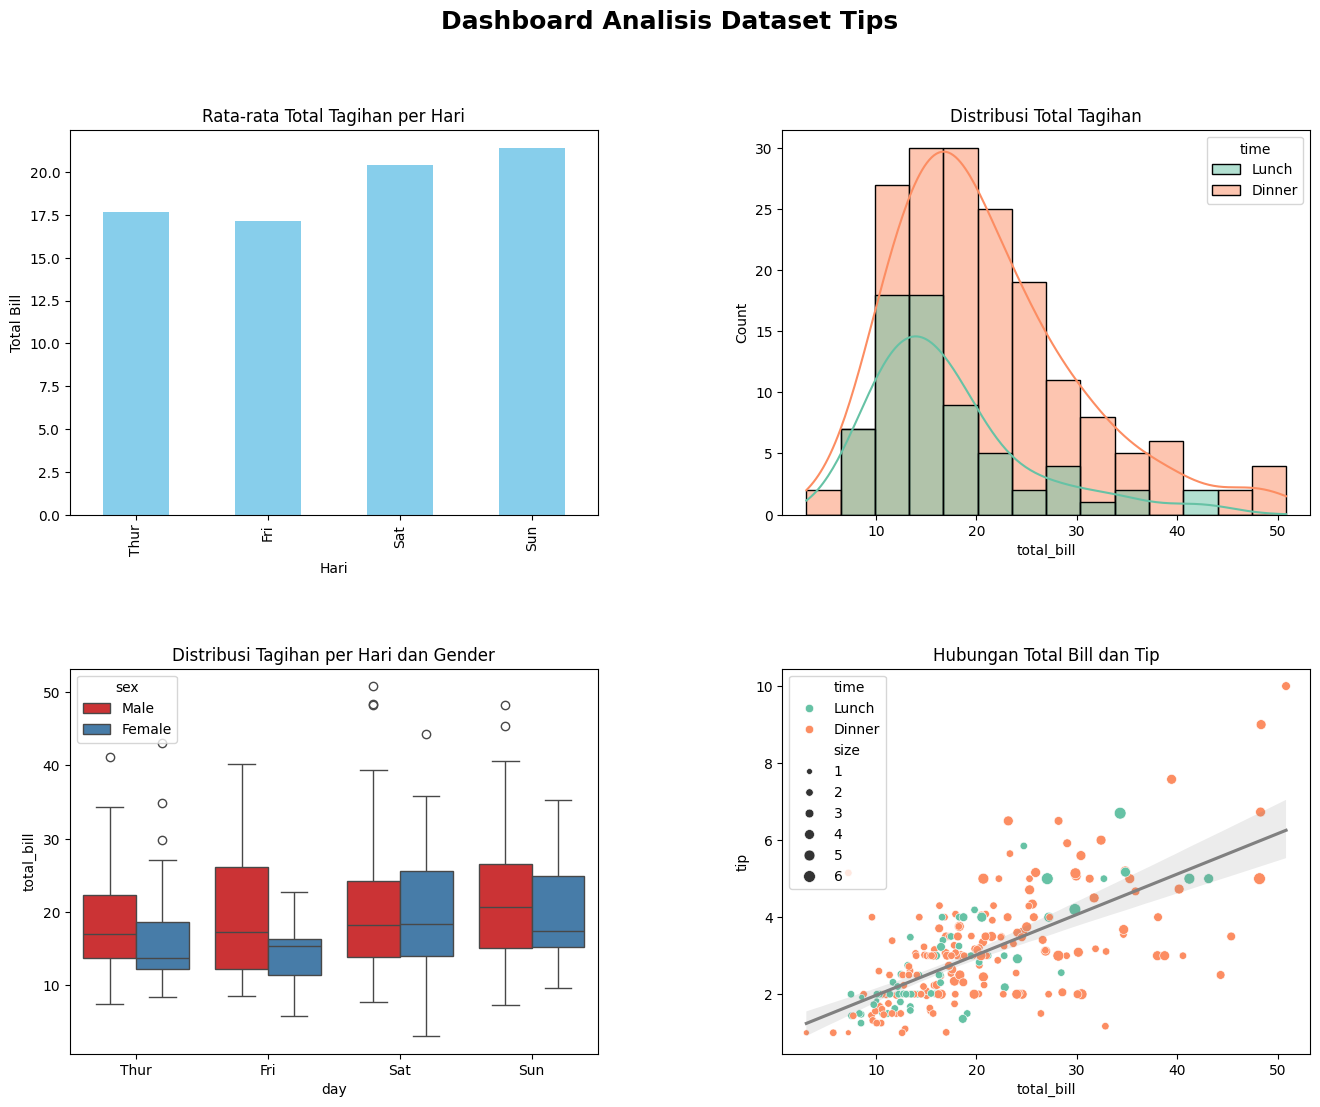

Dashboard berhasil dibuat


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset
df = sns.load_dataset('tips')

print(df.shape)
print(df.describe().round(2))

# Dashboard
fig = plt.figure(figsize=(16,12))
fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=18,
    fontweight='bold'
)

gs = gridspec.GridSpec(
    2,2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# Grafik 1 - Bar Chart
avg_by_day = df.groupby('day')['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='skyblue'
)

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill')

# Grafik 2 - Histogram
sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Tagihan')

# Grafik 3 - Boxplot
sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tagihan per Hari dan Gender')

# Grafik 4 - Scatter Plot
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    palette='Set2',
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Total Bill dan Tip')

plt.savefig(
    'dashboard_tips.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard berhasil dibuat")